In [1]:
import pandas as pd
from pandas import DataFrame
import numpy as np

In [2]:
import requests
import random
import xlrd
import csv
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
# formatting for decimal places
pd.set_option("display.float_format", "{:.2f}".format)

In [4]:
# setting seed for model reproducibility
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)

In [5]:
# setting the destination for the data folder
path = os.path.join(os.getcwd(), "../data")
norm_path = os.path.normpath(path)

In [6]:

from io import BytesIO


In [7]:

def download_xlsx_to_csv(month_list, base_url, output_dir="csv_output"):
    """
    Downloads .xlsx files from URLs and converts them to .csv files.

    Parameters:
    ----------
    month_list : list
        Example: ["2015_05", "2015_06", "2015_07"]

    base_url : str
        Example: "https://www.dmr.nd.gov/oilgas/mpr/"

    output_dir : str
        Folder where CSV files will be saved.
    """

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    for month in month_list:
        try:
            # Construct file URL
            file_url = f"{base_url}{month}.xlsx"

            print(f"Downloading: {file_url}")

            # Download file
            response = requests.get(file_url, timeout=30)
            response.raise_for_status()

            # Read Excel file into pandas dataframe
            excel_data = BytesIO(response.content)

            # Read first sheet
            df = pd.read_excel(excel_data, engine="openpyxl")

            # Output CSV path
            csv_filename = os.path.join(output_dir, f"{month}.csv")

            # Save as CSV
            df.to_csv(csv_filename, index=False)

            print(f"Saved CSV: {csv_filename}")

        except Exception as e:
            print(f"Failed for {month}: {e}")



In [8]:
train_list = ["2015_05","2015_06","2015_07","2015_08","2015_09","2015_10","2015_11","2015_12",
    "2016_01","2016_02","2016_03","2016_04","2016_05","2016_06","2016_07","2016_08","2016_09","2016_10","2016_11","2016_12",
    "2017_01","2017_02","2017_03","2017_04","2017_05","2017_06","2017_07","2017_08","2017_09","2017_10","2017_11","2017_12",
    "2018_01","2018_02","2018_03","2018_04","2018_05","2018_06","2018_07","2018_08","2018_09","2018_10","2018_11","2018_12"]

In [9]:
website = "https://www.dmr.nd.gov/oilgas/mpr/"

In [ ]:

download_xlsx_to_csv(train_list, website, output_dir='train_csv_output')

In [10]:
import glob

In [11]:

def combine_csv_files(input_dir="csv_output",
                      output_file="combined_data.csv"):
    """
    Combines all CSV files in a folder into a single CSV.

    Parameters:
    ----------
    input_dir : str
        Folder containing monthly CSV files.

    output_file : str
        Name/path of the final combined CSV file.
    """

    # Get all CSV files
    csv_files = glob.glob(os.path.join(input_dir, "*.csv"))

    if not csv_files:
        print("No CSV files found.")
        return

    dataframes = []

    for file in csv_files:
        try:
            print(f"Reading: {file}")

            # Read CSV
            df = pd.read_csv(file)

            # Optional: Add source month column
            month_name = os.path.basename(file).replace(".csv", "")
            df["source_month"] = month_name

            dataframes.append(df)

        except Exception as e:
            print(f"Failed to read {file}: {e}")

    # Combine all dataframes
    combined_df = pd.concat(dataframes, ignore_index=True)

    # Save combined CSV
    combined_df.to_csv(output_file, index=False)

    print(f"\nCombined CSV saved as: {output_file}")
    print(f"Total rows: {len(combined_df)}")


In [35]:

# Example usage
combine_csv_files(
    input_dir="C:\\Users\\ASUS\\Production\\data\\train_csv_output",
    output_file="C:\\Users\\ASUS\\training_combined.csv"
)

Reading: C:\Users\ASUS\Production\data\train_csv_output\2015_05.csv
Reading: C:\Users\ASUS\Production\data\train_csv_output\2015_06.csv
Reading: C:\Users\ASUS\Production\data\train_csv_output\2015_07.csv
Reading: C:\Users\ASUS\Production\data\train_csv_output\2015_08.csv
Reading: C:\Users\ASUS\Production\data\train_csv_output\2015_09.csv
Reading: C:\Users\ASUS\Production\data\train_csv_output\2015_10.csv
Reading: C:\Users\ASUS\Production\data\train_csv_output\2015_11.csv
Reading: C:\Users\ASUS\Production\data\train_csv_output\2015_12.csv
Reading: C:\Users\ASUS\Production\data\train_csv_output\2016_01.csv
Reading: C:\Users\ASUS\Production\data\train_csv_output\2016_02.csv
Reading: C:\Users\ASUS\Production\data\train_csv_output\2016_03.csv
Reading: C:\Users\ASUS\Production\data\train_csv_output\2016_04.csv
Reading: C:\Users\ASUS\Production\data\train_csv_output\2016_05.csv
Reading: C:\Users\ASUS\Production\data\train_csv_output\2016_06.csv
Reading: C:\Users\ASUS\Production\data\train_csv

In [12]:
test_list = ["2019_01","2019_02","2019_03","2019_04","2019_05","2019_06","2019_07","2019_08","2019_09","2019_10","2019_11","2019_12"]

In [ ]:
download_xlsx_to_csv(test_list, website, output_dir="test_csv_output")

In [36]:
combine_csv_files(
    input_dir="C:\\Users\\ASUS\\Production\\data\\test_csv_output",
    output_file="C:\\Users\\ASUS\\testing_combined.csv"
)

Reading: C:\Users\ASUS\Production\data\test_csv_output\2019_01.csv
Reading: C:\Users\ASUS\Production\data\test_csv_output\2019_02.csv
Reading: C:\Users\ASUS\Production\data\test_csv_output\2019_03.csv
Reading: C:\Users\ASUS\Production\data\test_csv_output\2019_04.csv
Reading: C:\Users\ASUS\Production\data\test_csv_output\2019_05.csv
Reading: C:\Users\ASUS\Production\data\test_csv_output\2019_06.csv
Reading: C:\Users\ASUS\Production\data\test_csv_output\2019_07.csv
Reading: C:\Users\ASUS\Production\data\test_csv_output\2019_08.csv
Reading: C:\Users\ASUS\Production\data\test_csv_output\2019_09.csv
Reading: C:\Users\ASUS\Production\data\test_csv_output\2019_10.csv
Reading: C:\Users\ASUS\Production\data\test_csv_output\2019_11.csv
Reading: C:\Users\ASUS\Production\data\test_csv_output\2019_12.csv

Combined CSV saved as: C:\Users\ASUS\testing_combined.csv
Total rows: 215017


In [22]:
# ARPS Decline Curve Analysis

def pre_process(df, column):
    #df.drop("Unnamed: 0", axis=1, inplace=True)
    df.info()
    print(df.columns)
    # descriptive statistics
    df.describe().T
    df.head(15)
    df.nunique()    
    df.dtypes
    df.shape
    # filtering
    df.dropna(inplace=True)
    # drop rows where oil rate is 0
    df = df[(df[column].notnull()) & (df[column] > 0)]
    return df


In [14]:
# visualization/plotting libraries
import matplotlib as mpl
import matplotlib.style
import seaborn as sns  
import matplotlib.pyplot as plt
# setting to default parameters
plt.rcParams.update(plt.rcParamsDefault)

In [15]:
# matplotlib settings
mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use('seaborn-v0_8-white')
mpl.rcParams["figure.figsize"] = (12, 8)
mpl.rcParams["axes.grid"] = False

In [16]:


def plot_production_rate(df):
    '''Plot decline curve using production rates'''
    sns.lineplot(x = df['ReportDate'], y = df['oil_rate'], markers=True, dashes=False, 
                 label="Oil Production",color='blue', linewidth=1.5)
    plt.title('Decline Curve', fontweight='bold', fontsize = 20)
    plt.xlabel('Time', fontweight='bold', fontsize = 15)
    plt.ylabel('Oil Production Rate (bbl/d)', fontweight='bold', fontsize = 15)
    plt.show()



In [17]:

def decline_curve(curve_type, q_i):
    if curve_type == "exponential":

        def exponential_decline(T, d):
            return q_i * np.exp(-d * T)
        return exponential_decline

    elif curve_type == "hyperbolic":

        def hyperbolic_decline(T, d_i, b):
            return q_i / np.power((1 + b * d_i * T), 1.0 / b)
        return hyperbolic_decline

    elif curve_type == "harmonic":

        def parabolic_decline(T, d_i):
            return q_i / (1 + d_i * T)
        return parabolic_decline

    else:
        raise "Unknown Decline Curve!"


In [18]:


def L2_norm(Q, Q_obs):
    return np.sum(np.power(np.subtract(Q, Q_obs), 2))

In [37]:
# reading train and test data
train_prod = pd.read_csv('C:\\Users\\ASUS\\training_combined.csv')
test_prod = pd.read_csv("C:\\Users\\ASUS\\testing_combined.csv")

In [38]:

# Basic Processing and data exploration
train_prod = pre_process(train_prod,column="Oil")
test_prod = pre_process(test_prod, column="Oil")

<class 'pandas.DataFrame'>
RangeIndex: 684415 entries, 0 to 684414
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ReportDate    684415 non-null  str    
 1   API_WELLNO    684415 non-null  int64  
 2   FileNo        684415 non-null  int64  
 3   Company       684415 non-null  str    
 4   WellName      684415 non-null  str    
 5   Quarter       684415 non-null  str    
 6   Section       684415 non-null  int64  
 7   Township      684415 non-null  int64  
 8   Range         684415 non-null  int64  
 9   County        684415 non-null  str    
 10  FieldName     684415 non-null  str    
 11  Pool          684415 non-null  str    
 12  Oil           678599 non-null  float64
 13  Wtr           678599 non-null  float64
 14  Days          678599 non-null  float64
 15  Runs          684415 non-null  int64  
 16  Gas           678599 non-null  float64
 17  GasSold       684415 non-null  int64  
 18  Flared        6

In [39]:
# convert time to datetime and set as dataframe index
train_prod["ReportDate"] = pd.to_datetime(train_prod["ReportDate"])
test_prod["ReportDate"] = pd.to_datetime(test_prod["ReportDate"])

In [40]:
#bakken_data.set_index("ReportDate", inplace=True)
train_prod["First_Prod_Date"] = train_prod.groupby("API_WELLNO")["ReportDate"].transform('min')
train_prod["Days_Online"] = (train_prod["ReportDate"] - train_prod["First_Prod_Date"]).dt.days 

In [42]:
# find the top 10 wells with highest production (sum)
grouped_data = train_prod.groupby(['API_WELLNO']).sum(numeric_only=True)
grouped_data = grouped_data.sort_values(by=['Oil'])
grouped_data = grouped_data.nlargest(10, 'Oil').reset_index()

In [43]:
example_wells = grouped_data['API_WELLNO'].to_numpy()

[33025026210000 33053059200000 33053056530000 33053074110000
 33053057830000 33053059210000 33053059170000 33053059190000
 33025021780000 33055001360000]
API: [33053059210000, 33025021780000]


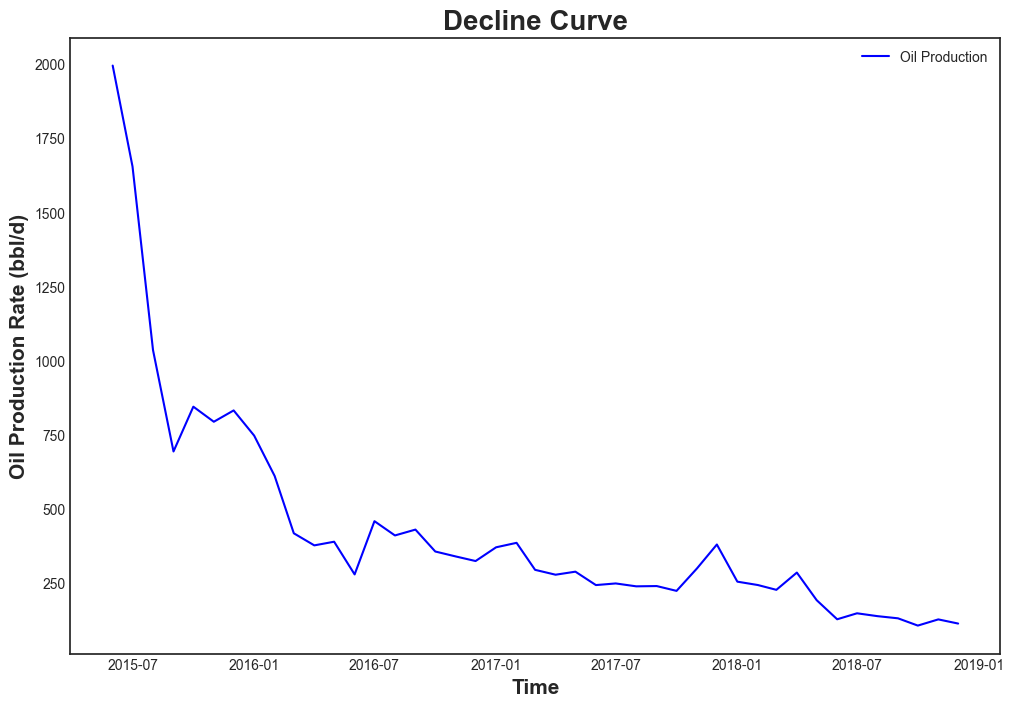

In [44]:
print (example_wells)
demo_well = [33053059210000, 33025021780000]

print('API:', demo_well)
df_temp = train_prod[train_prod['API_WELLNO'] == demo_well[1]]
df_temp["oil_rate"] = df_temp["Oil"] / df_temp["Days"]
df_temp['date_delta'] = (df_temp['ReportDate'] - df_temp['ReportDate'].min())/np.timedelta64(1,'D')
plot_production_rate(df_temp)

In [45]:
df_temp = df_temp[['date_delta', 'oil_rate']]
data = df_temp.to_numpy()
# T is number of days of production - cumulative
# q is production rate
T_train, q = data.T
print(T_train)
print(q)

[   0.   30.   61.   92.  122.  153.  183.  214.  245.  274.  305.  335.
  366.  396.  427.  458.  488.  519.  549.  580.  611.  639.  670.  700.
  731.  761.  792.  823.  853.  884.  914.  945.  976. 1004. 1035. 1065.
 1096. 1126. 1157. 1188. 1218. 1249. 1279.]
[1994.9375     1654.4516129  1035.4         693.36666667  844.4516129
  793.62068966  831.80645161  746.90322581  610.75862069  417.38095238
  376.63333333  388.96774194  278.68965517  458.23076923  410.12903226
  429.86666667  355.96774194  339.26666667  323.80769231  370.125
  385.21428571  294.12903226  277.66666667  287.93548387  242.73333333
  248.22580645  238.48387097  239.4137931   223.16129032  299.1
  379.57142857  254.24137931  242.88461538  226.68965517  284.86206897
  191.76666667  127.36666667  147.5483871   137.90322581  130.6
  106.09677419  126.96551724  112.93548387]


In [48]:
from scipy.optimize import curve_fit

In [49]:
# Assumption - determine qi from max value of first 3 months of production
df_initial_period = df_temp.head(3)
qi = df_initial_period['oil_rate'].max()

exp_decline = decline_curve("exponential", qi)
hyp_decline = decline_curve("hyperbolic", qi)
har_decline = decline_curve("harmonic", qi)

popt_exp, pcov_exp = curve_fit(exp_decline, T_train, q, method="trf")
popt_hyp, pcov_hyp = curve_fit(hyp_decline, T_train, q, method="trf")
popt_har, pcov_har = curve_fit(har_decline, T_train, q, method="trf")

print("L2 Norm of exponential decline: ", L2_norm(exp_decline(T_train, popt_exp[0]), q))
print("L2 Norm of hyperbolic decline decline: ",L2_norm(hyp_decline(T_train, popt_hyp[0], popt_hyp[1]), q))
print("L2 Norm of harmonic decline decline: ", L2_norm(har_decline(T_train, popt_har[0]), q))

L2 Norm of exponential decline:  10167505.41462357
L2 Norm of hyperbolic decline decline:  309675.9298070143
L2 Norm of harmonic decline decline:  361356.90904455684


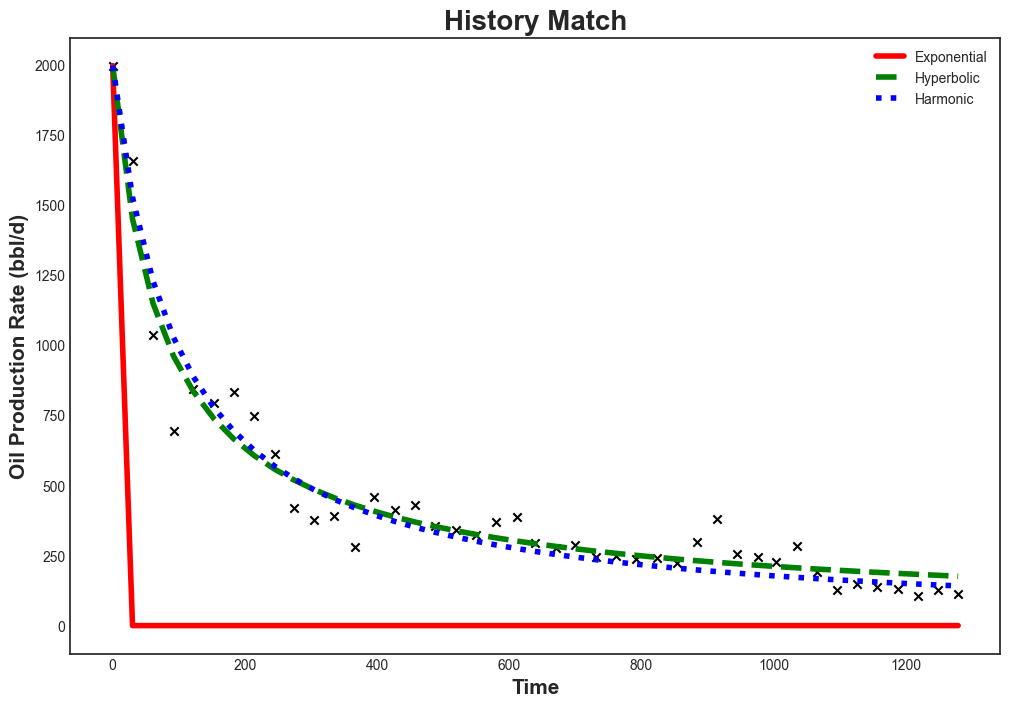

In [50]:
# Predict
plt.scatter(T_train, q, color="black", marker="x", alpha=1)
pred_exp = exp_decline(T_train, popt_exp[0])
pred_hyp = hyp_decline(T_train, popt_hyp[0], popt_hyp[1])
pred_har = har_decline(T_train, popt_har[0])
plt.plot(T_train, pred_exp, color="red", label="Exponential", linewidth = 4)
plt.plot(T_train, pred_hyp, color="green", label="Hyperbolic", linestyle="--", linewidth = 4)
plt.plot(T_train, pred_har, color="blue", label="Harmonic", linestyle = ':', linewidth = 4)
plt.title('History Match', fontweight='bold', fontsize = 20)
plt.xlabel('Time', fontweight='bold', fontsize = 15)
plt.ylabel('Oil Production Rate (bbl/d)', fontweight='bold', fontsize = 15)
plt.legend(loc='best')
plt.show()

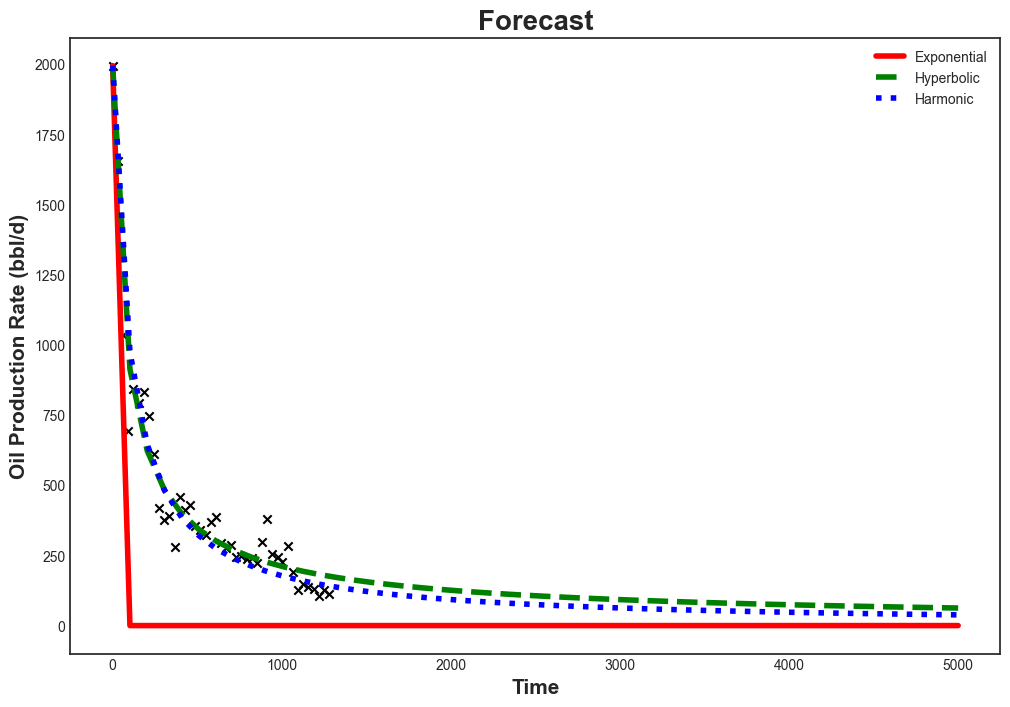

In [51]:
# Forecast
max_time_forecast = 5000
T_pred = np.linspace(min(T_train), max_time_forecast)
plt.scatter(T_train, q, color="black", marker="x", alpha=1)
pred_exp = exp_decline(T_pred, popt_exp[0])
pred_hyp = hyp_decline(T_pred, popt_hyp[0], popt_hyp[1])
pred_har = har_decline(T_pred, popt_har[0])
plt.plot(T_pred, pred_exp, color="red", label="Exponential", linewidth = 4)
plt.plot(T_pred, pred_hyp, color="green", label="Hyperbolic", linestyle="--", linewidth = 4)
plt.plot(T_pred, pred_har, color="blue", label="Harmonic", linestyle = ':', linewidth = 4)
plt.title('Forecast', fontweight='bold', fontsize = 20)
plt.xlabel('Time', fontweight='bold', fontsize = 15)
plt.ylabel('Oil Production Rate (bbl/d)', fontweight='bold', fontsize = 15)
plt.legend(loc='best')
plt.show()

In [52]:
# validation procedure

print('API:', demo_well[1])
df_temp_test = test_prod[test_prod['API_WELLNO'] == demo_well[1]]
df_temp_test["oil_rate"] = df_temp_test["Oil"] / df_temp_test["Days"]
df_temp_test['date_delta'] = (df_temp_test['ReportDate'] - df_temp_test['ReportDate'].min())  / np.timedelta64(1,'D')
print(df_temp_test)
df_temp_test = df_temp_test[['date_delta', 'oil_rate']]
data_test = df_temp_test.to_numpy()
# T is number of days of production - cumulative
# q is production rate
T_test, q_test = data_test.T

#T_test = np.concatenate(T_train, T)
print(T_test)
print(q_test)

API: 33025021780000
       ReportDate      API_WELLNO  FileNo                             Company  \
9237   2019-01-01  33025021780000   25736  ENERPLUS RESOURCES USA CORPORATION   
26666  2019-02-01  33025021780000   25736  ENERPLUS RESOURCES USA CORPORATION   
44161  2019-03-01  33025021780000   25736  ENERPLUS RESOURCES USA CORPORATION   
61730  2019-04-01  33025021780000   25736  ENERPLUS RESOURCES USA CORPORATION   
79421  2019-05-01  33025021780000   25736  ENERPLUS RESOURCES USA CORPORATION   
97225  2019-06-01  33025021780000   25736  ENERPLUS RESOURCES USA CORPORATION   
115149 2019-07-01  33025021780000   25736  ENERPLUS RESOURCES USA CORPORATION   
133202 2019-08-01  33025021780000   25736  ENERPLUS RESOURCES USA CORPORATION   
151359 2019-09-01  33025021780000   25736  ENERPLUS RESOURCES USA CORPORATION   
169616 2019-10-01  33025021780000   25736  ENERPLUS RESOURCES USA CORPORATION   
187967 2019-11-01  33025021780000   25736  ENERPLUS RESOURCES USA CORPORATION   

       

In [53]:
time = pd.date_range(start='6/1/2015', periods= 54, freq='MS')
time
T_Test2 = T_train[-1] + T_test
len(T_train)
pred_hyp =  hyp_decline(T_train, popt_hyp[0], popt_hyp[1])
pred_hyp2 = hyp_decline(T_Test2, popt_hyp[0], popt_hyp[1])
print(pred_hyp)
print(pred_hyp2)
# forecast
q_orig = np.append(q, q_test)
forecast = np.concatenate([pred_hyp, pred_hyp2])

[1994.9375     1448.62576854 1148.0411834   960.09163612  833.84616277
  737.35543225  665.22003735  605.68592908  557.07659264  518.96359763
  484.25039057  455.32203047  429.27541849  407.09626649  386.75357082
  368.59446636  352.7743085   337.96976599  324.9278321   312.60103419
  301.29356482  291.85138711  282.1531322   273.44126552  265.05961108
  257.48694399  250.16247644  243.29749648  237.05043997  230.96768963
  225.41034911  219.97896665  214.83776676  210.42390554  205.77211473
  201.48820436  197.26992962  193.37505307  189.53031727  185.85597105
  182.45153427  179.07982986  175.94945366]
[175.94945366 172.8431687  170.14306169 167.26370133 164.58108997
 161.91023237 159.41799863 156.93297692 154.53476653 152.29219382
 150.0515489 ]


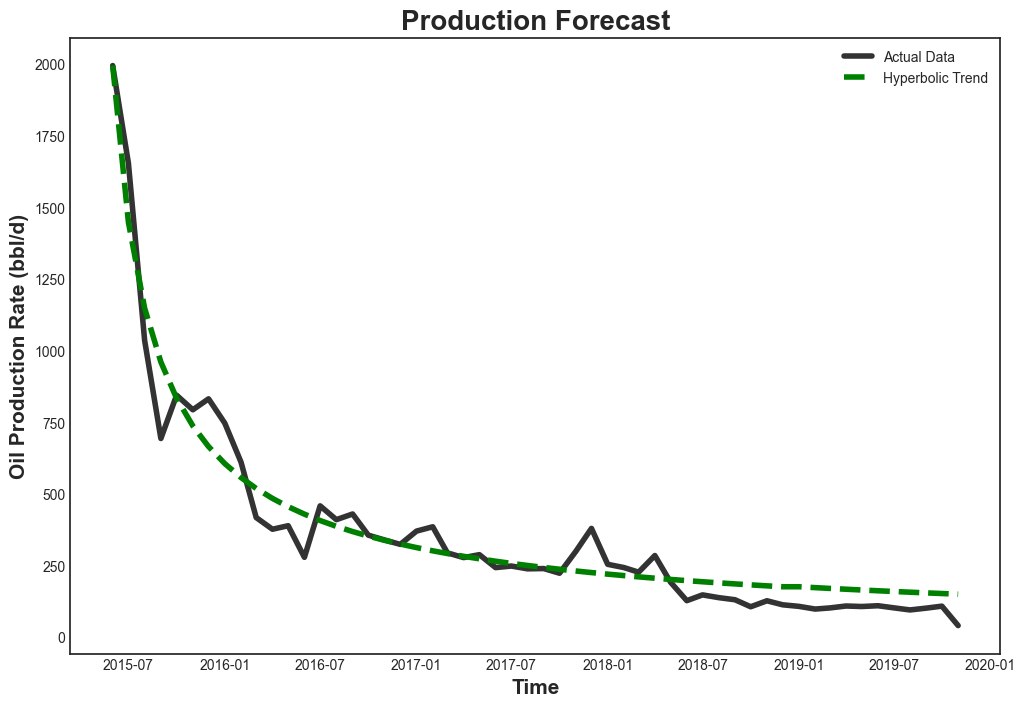

In [54]:
# hyperbolic forecast - plot
plt.plot(time, q_orig, color="black", alpha = 0.8, label='Actual Data', linewidth = 4)
plt.plot(time, forecast, color="green", label="Hyperbolic Trend", linewidth = 4, linestyle="--")
plt.title('Production Forecast', fontweight='bold', fontsize = 20)
plt.xlabel('Time', fontweight='bold', fontsize = 15)
plt.ylabel('Oil Production Rate (bbl/d)', fontweight='bold', fontsize = 15)
plt.legend(loc='best')
plt.show()

In [60]:
from math import sqrt

In [63]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error


In [65]:
rmse = sqrt(mean_squared_error(q_orig, forecast))
print("RMSE - Hyperbolic Method:", rmse)

RMSE - Hyperbolic Method: 81.41922166932933


## ARIMA MODEL BASED DCA

In [67]:
def plot_production_series(series):
    plt.figure(figsize=(10, 6))
    plt.plot(series, color = 'blue')
    plt.title("Oil Production Decline")
    plt.xlabel("Year")
    plt.ylabel("Production Rate (bbls/d)")
    plt.show()

In [70]:
# data 
train_prod = pd.read_csv(r'C:\Users\ASUS\training_combined.csv')
test_prod = pd.read_csv(r'C:\Users\ASUS\testing_combined.csv')
print('Training Data:\n', train_prod.head(10))
print('\n')
print('Test Data:\n', train_prod.head(10))

Training Data:
    ReportDate      API_WELLNO  FileNo                      Company  \
0  2015-05-01  33053043310000   23615  MUREX PETROLEUM CORPORATION   
1  2015-05-01  33053038990000   22021         STATOIL OIL & GAS LP   
2  2015-05-01  33053048330000   25091         STATOIL OIL & GAS LP   
3  2015-05-01  33053050010000   25645         STATOIL OIL & GAS LP   
4  2015-05-01  33053048340000   25092         STATOIL OIL & GAS LP   
5  2015-05-01  33053050000000   25644         STATOIL OIL & GAS LP   
6  2015-05-01  33053039010000   22023         STATOIL OIL & GAS LP   
7  2015-05-01  33053042390000   23319         STATOIL OIL & GAS LP   
8  2015-05-01  33053042400000   23320         STATOIL OIL & GAS LP   
9  2015-05-01  33053042380000   23302         STATOIL OIL & GAS LP   

                   WellName Quarter  Section  Township  Range County  ...  \
0   AMBER ELIZABETH  36-25H    SESW       36       151    101    MCK  ...   
1          BILL  14-23 2TFH    SWSW       11       151    1

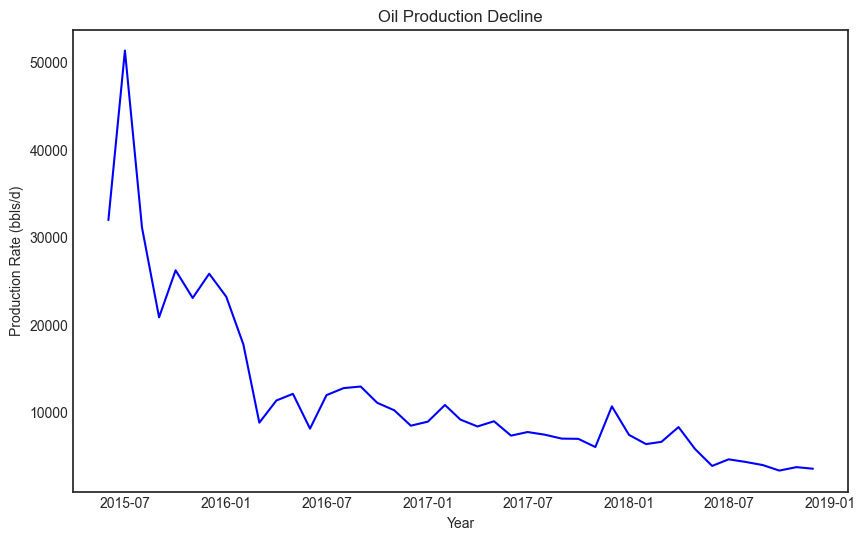

In [72]:
# Preprocessing on train data
# well selection for demo - time series
train_prod = train_prod[train_prod["API_WELLNO"] == 33025021780000.0]
#train_prod.drop("Unnamed: 0", axis=1, inplace=True)
train_prod["ReportDate"] = pd.to_datetime(train_prod["ReportDate"])
train_prod.set_index("ReportDate", inplace=True)
train_prod.nunique()

# converting data from dataframe to series - oil production
timeseries_train= train_prod["Oil"]
timeseries_train.head()
plot_production_series(timeseries_train)

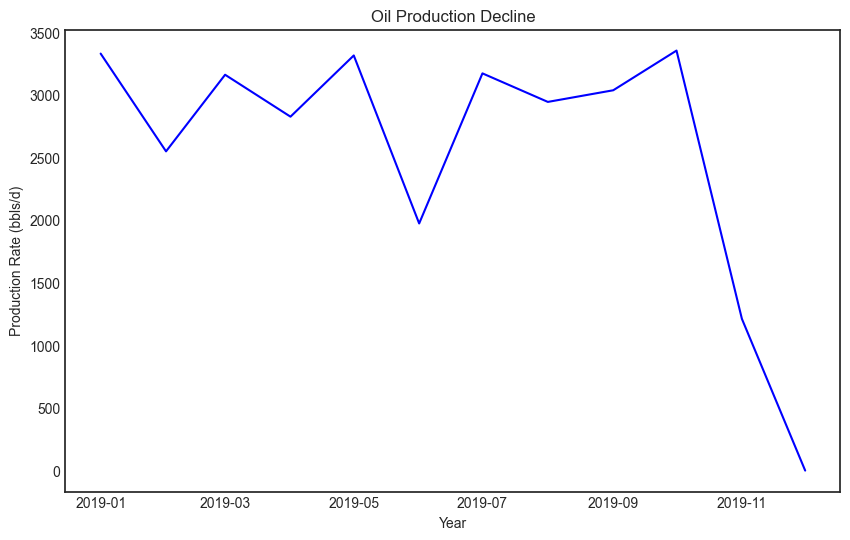

In [73]:
# Preprocessing on test data
# well selection for demo - time series
test_prod = test_prod[test_prod["API_WELLNO"] == 33025021780000.0]
#test_prod.drop("Unnamed: 0", axis=1, inplace=True)
test_prod["ReportDate"] = pd.to_datetime(test_prod["ReportDate"])
test_prod.set_index("ReportDate", inplace=True)
test_prod.nunique()

# time series is production volumes and not flow rates
timeseries_test = test_prod["Oil"]
timeseries_test.head()
plot_production_series(timeseries_test)

In [76]:
from statsmodels.tsa.stattools import adfuller

In [77]:
# ADF - Augmented Dickey-Fuller unit root test - to test stationarity
print("p-value:", adfuller(timeseries_train.dropna())[1])

p-value: 0.8121709155138293


In [78]:
# Perform Dickey-Fuller test:
def dickey_ful_test(series):
    print("Results of Dickey-Fuller Test:")
    df_test = adfuller(series, autolag="AIC")
    df_output = pd.Series(df_test[0:4],index=["Test Statistic","p-value","#Lags Used","Number of Observations Used"])
    for key, value in df_test[4].items():
        df_output["Critical Value (%s)" % key] = value
    print(df_output)

In [79]:
def stationary_test_plot(metric, data_series, method):
    plt.figure(figsize=(10, 6))
    orig = plt.plot(data_series, label="Original", color = 'blue')
    metric = plt.plot(metric, label= method, color ='red')
    plt.legend(loc="best")
    plt.title(method)
    plt.xlabel('Time (yyyy-mm)')
    plt.ylabel('Oil Production (bbls)')
    plt.show()

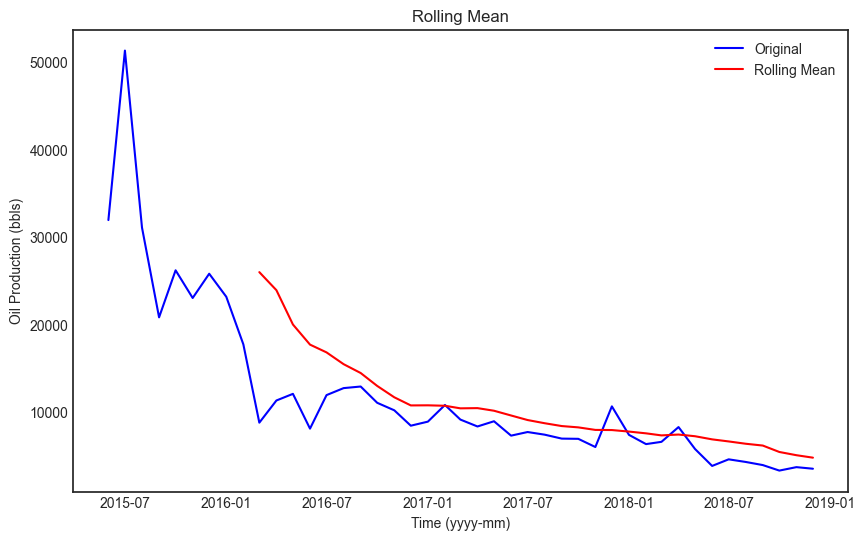

Results of Dickey-Fuller Test:
Test Statistic                -0.82
p-value                        0.81
#Lags Used                     9.00
Number of Observations Used   33.00
Critical Value (1%)           -3.65
Critical Value (5%)           -2.95
Critical Value (10%)          -2.62
dtype: float64


In [80]:
def stationary_test(data_series, method):
    rolling_mean = data_series.rolling(10).mean()
    stationary_test_plot(rolling_mean, data_series, method)
    dickey_ful_test(data_series)

# test if the time series data is stationary or not
stationary_test(timeseries_train, "Rolling Mean")

In [81]:
def plot_time_series(y_axis, x_label, y_label, title):
    plt.figure(figsize=(10, 6))
    plt.plot(y_axis, label = y_label, color = 'blue')
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

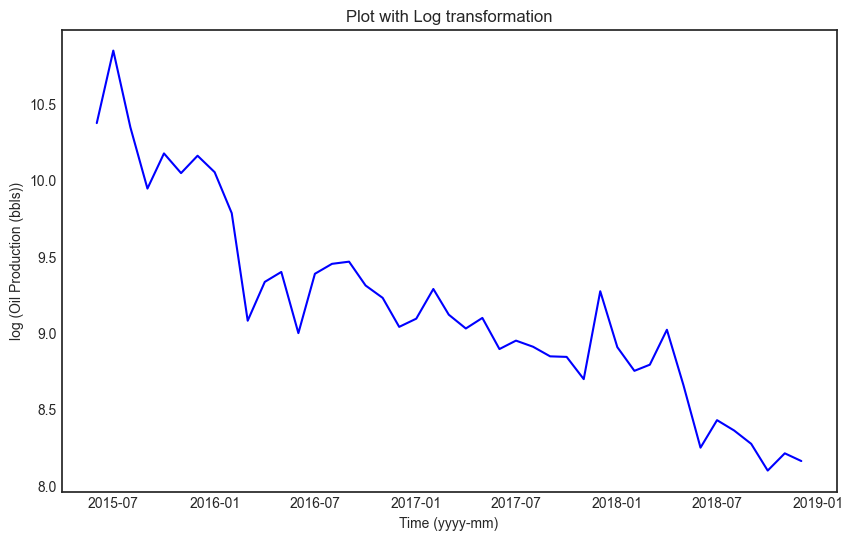

In [82]:
# y axis transformation - log(data)
ts_log = np.log(timeseries_train)
plot_time_series(ts_log, "Time (yyyy-mm)", "log (Oil Production (bbls))", "Plot with Log transformation")

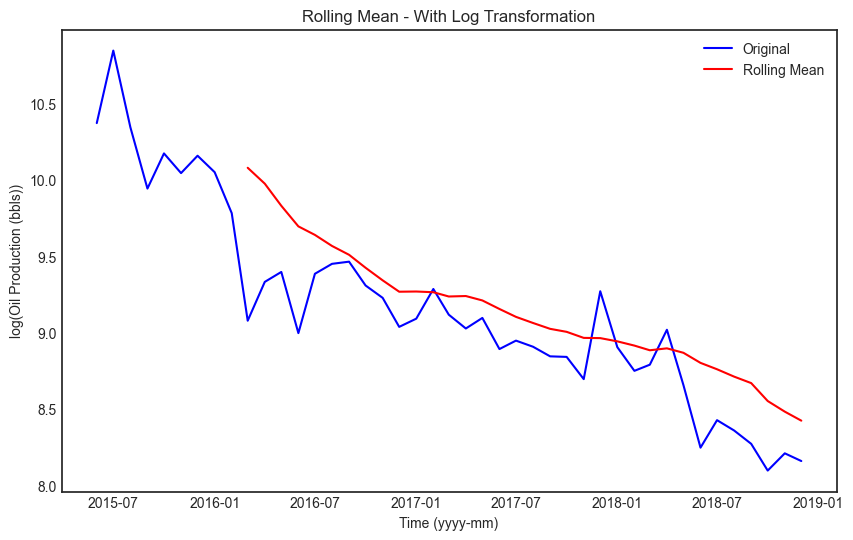

In [83]:
# rolling mean estimation and plot
rolling_mean_log = ts_log.rolling(10).mean()

plt.figure(figsize=(10, 6))
orig = plt.plot(ts_log, label="Original", color = 'blue')
mean = plt.plot(rolling_mean_log, label="Rolling Mean", color ='red')
plt.title("Rolling Mean - With Log Transformation")
plt.xlabel('Time (yyyy-mm)')
plt.ylabel('log(Oil Production (bbls))')
plt.legend(loc="best")
plt.show()

In [84]:
# plot of difference between log(data) and moving average
diff_log_rolmean = ts_log - rolling_mean_log
diff_log_rolmean.dropna(inplace=True)

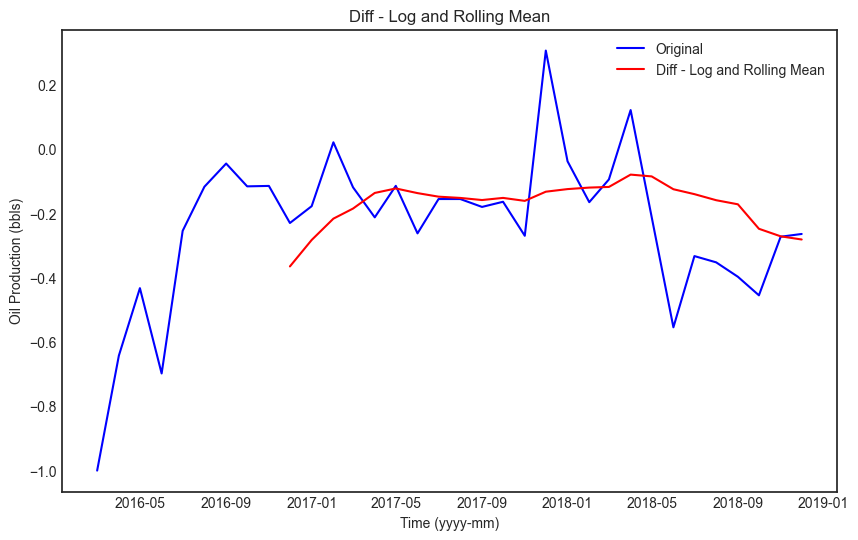

Results of Dickey-Fuller Test:
Test Statistic                -1.36
p-value                        0.60
#Lags Used                     7.00
Number of Observations Used   26.00
Critical Value (1%)           -3.71
Critical Value (5%)           -2.98
Critical Value (10%)          -2.63
dtype: float64


In [85]:
stationary_test(diff_log_rolmean, "Diff - Log and Rolling Mean")

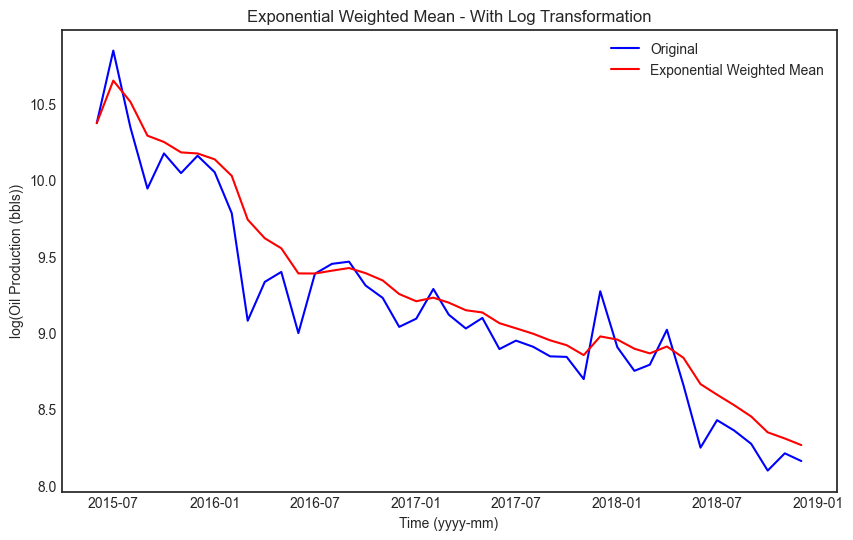

In [86]:
# exponential weighted calculations
weighted_avg_exp = ts_log.ewm(halflife=2).mean()
plt.figure(figsize=(10, 6))

orig = plt.plot(ts_log, label="Original", color = 'blue')
mean = plt.plot(weighted_avg_exp, label="Exponential Weighted Mean", color ='red')
plt.title("Exponential Weighted Mean - With Log Transformation")
plt.xlabel('Time (yyyy-mm)')
plt.ylabel('log(Oil Production (bbls))')
plt.legend(loc="best")
plt.show()

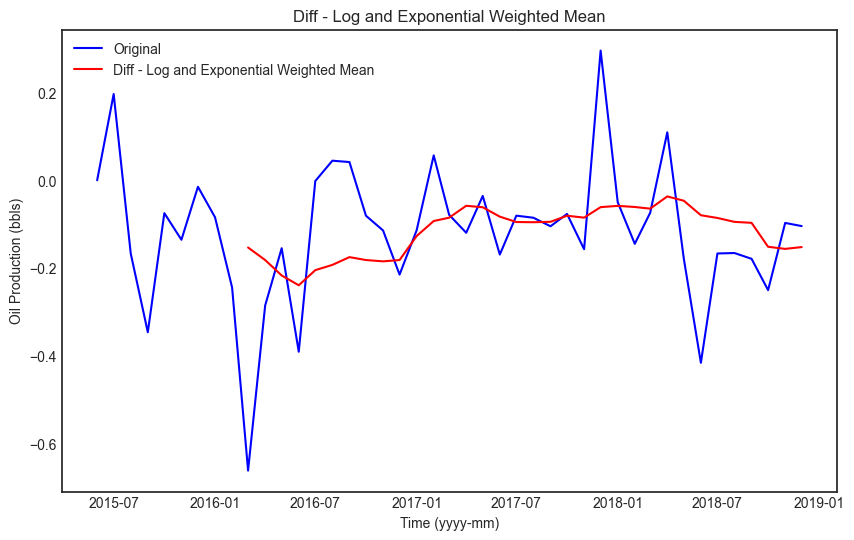

Results of Dickey-Fuller Test:
Test Statistic                -4.95
p-value                        0.00
#Lags Used                     0.00
Number of Observations Used   42.00
Critical Value (1%)           -3.60
Critical Value (5%)           -2.93
Critical Value (10%)          -2.60
dtype: float64


In [87]:
diff_log_ewm = ts_log - weighted_avg_exp
stationary_test(diff_log_ewm, "Diff - Log and Exponential Weighted Mean")

In [88]:
# First Order differencing - n this technique, we take the difference of the observation at a particular instant with 
# that at the previous instant. This mostly works well in improving stationarity

# Differencing can help stabilize the mean of the time series by removing changes in the level of a time series,
# and so eliminating (or reducing) trend and seasonality
# https://machinelearningmastery.com/difference-time-series-dataset-python/

first_order_diff = ts_log - ts_log.shift()

<Figure size 1000x600 with 0 Axes>

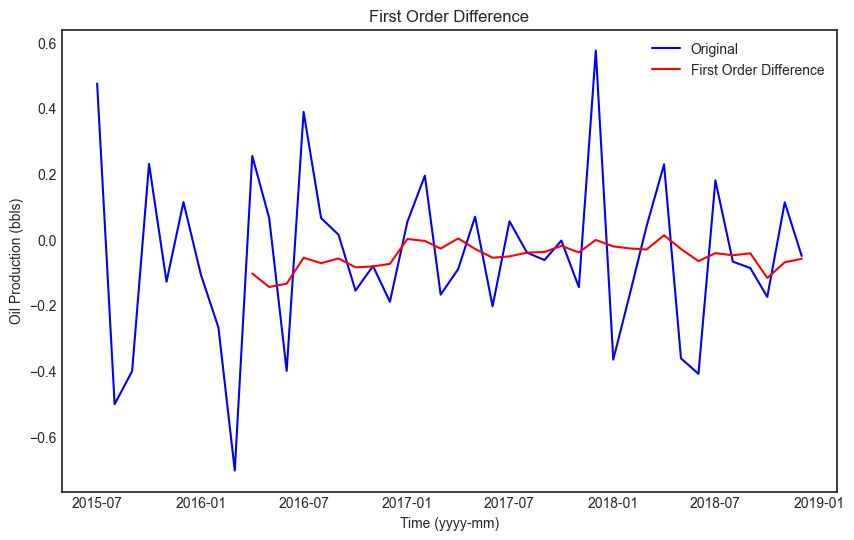

Results of Dickey-Fuller Test:
Test Statistic                -7.22
p-value                        0.00
#Lags Used                     1.00
Number of Observations Used   40.00
Critical Value (1%)           -3.61
Critical Value (5%)           -2.94
Critical Value (10%)          -2.61
dtype: float64


In [89]:
first_order_diff.dropna(inplace=True)
plt.figure(figsize=(10, 6))
stationary_test(first_order_diff, "First Order Difference")

In [90]:
ts_log_diff_active = first_order_diff

In [95]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf

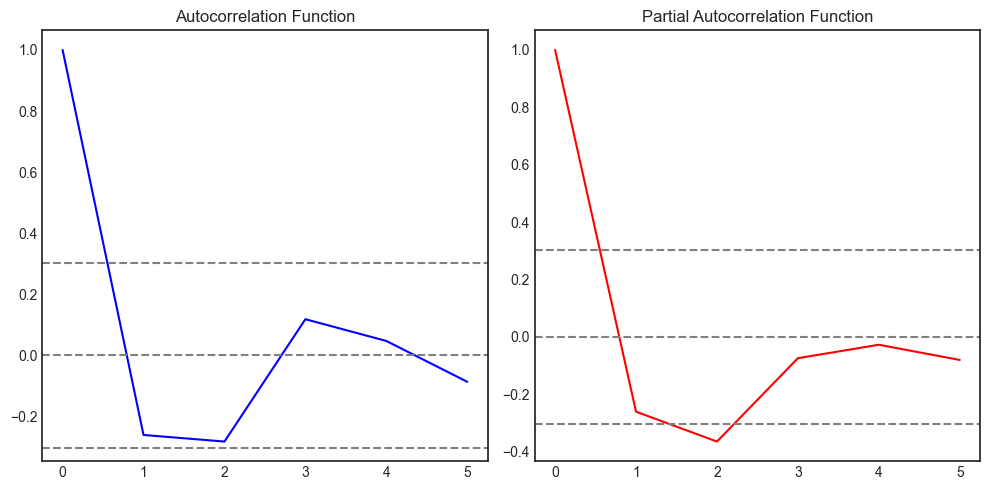

In [96]:

lag_acf = acf(ts_log_diff_active, nlags=5)
lag_pacf = pacf(ts_log_diff_active, nlags=5, method="ols")
plt.figure(figsize=(10, 5))

# Plot ACF:
plt.subplot(121)
plt.plot(lag_acf, color = 'blue')
plt.axhline(y=0, linestyle="--", color="gray")
plt.axhline(y=-1.96 / np.sqrt(len(ts_log_diff_active)), linestyle="--", color="gray")
plt.axhline(y=1.96 / np.sqrt(len(ts_log_diff_active)), linestyle="--", color="gray")
plt.title("Autocorrelation Function")

# Plot PACF:
plt.subplot(122)
plt.plot(lag_pacf, color = 'red')
plt.axhline(y=0, linestyle="--", color="gray")
plt.axhline(y=-1.96 / np.sqrt(len(ts_log_diff_active)), linestyle="--", color="gray")
plt.axhline(y=1.96 / np.sqrt(len(ts_log_diff_active)), linestyle="--", color="gray")
plt.title("Partial Autocorrelation Function")
plt.tight_layout()
plt.show()


In [98]:
from statsmodels.tsa.arima.model import ARIMA

c:\Users\ASUS\Production\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ASUS\Production\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ASUS\Production\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


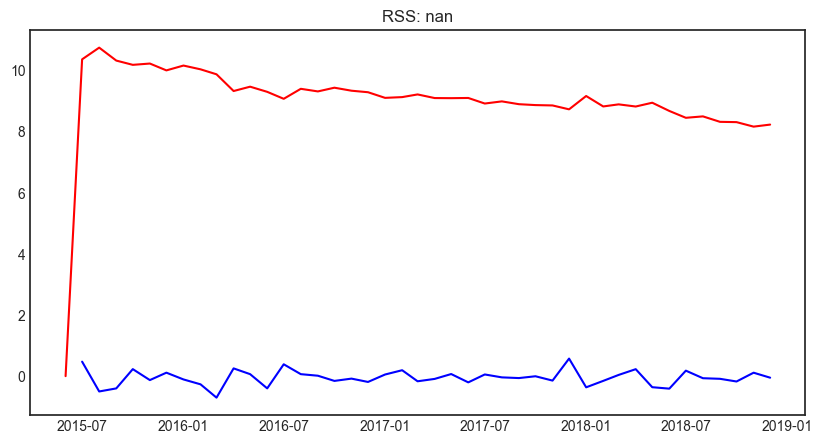

In [101]:
# Auto-Regressive Model (p=2, d=1, q=0)
model_AR = ARIMA(ts_log, order=(2, 1, 0))
results_ARIMA_AR = model_AR.fit()
plt.figure(figsize=(10, 5))
plt.plot(ts_log_diff_active, color = 'blue')
plt.plot(results_ARIMA_AR.fittedvalues, color="red")
plt.title("RSS: %.3f" % sum((results_ARIMA_AR.fittedvalues - first_order_diff) ** 2))
plt.show()

c:\Users\ASUS\Production\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ASUS\Production\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ASUS\Production\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


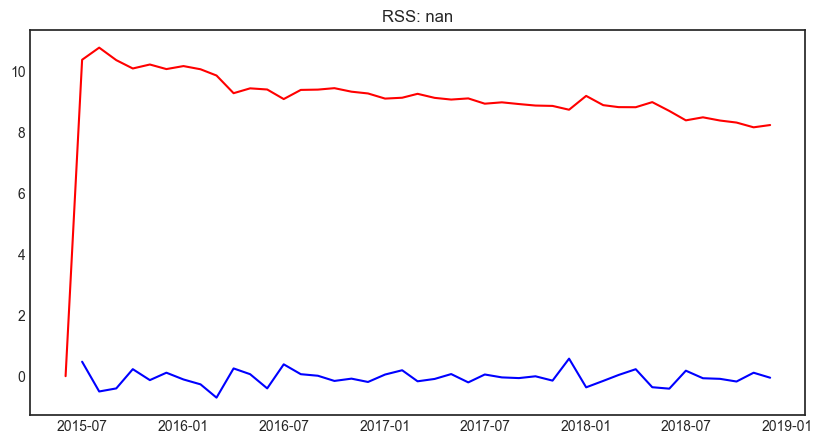

In [102]:
# Moving Average Model (p=0, d=1, q=2)
model_MA = ARIMA(ts_log, order=(0, 1, 2))
results_ARIMA_MA = model_MA.fit()
plt.figure(figsize=(10, 5))
plt.plot(ts_log_diff_active, color = 'blue')
plt.plot(results_ARIMA_MA.fittedvalues, color="red")
plt.title("RSS: %.3f" % sum((results_ARIMA_MA.fittedvalues - first_order_diff) ** 2))
plt.show()

c:\Users\ASUS\Production\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ASUS\Production\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ASUS\Production\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    Oil   No. Observations:                   43
Model:                 ARIMA(2, 1, 2)   Log Likelihood                  -0.130
Date:                Mon, 18 May 2026   AIC                             10.260
Time:                        14:38:18   BIC                             18.948
Sample:                    06-01-2015   HQIC                            13.445
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3413      0.525     -0.650      0.516      -1.371       0.688
ar.L2         -0.5343      0.478     -1.118      0.264      -1.471       0.402
ma.L1          0.1084      0.576      0.188      0.8

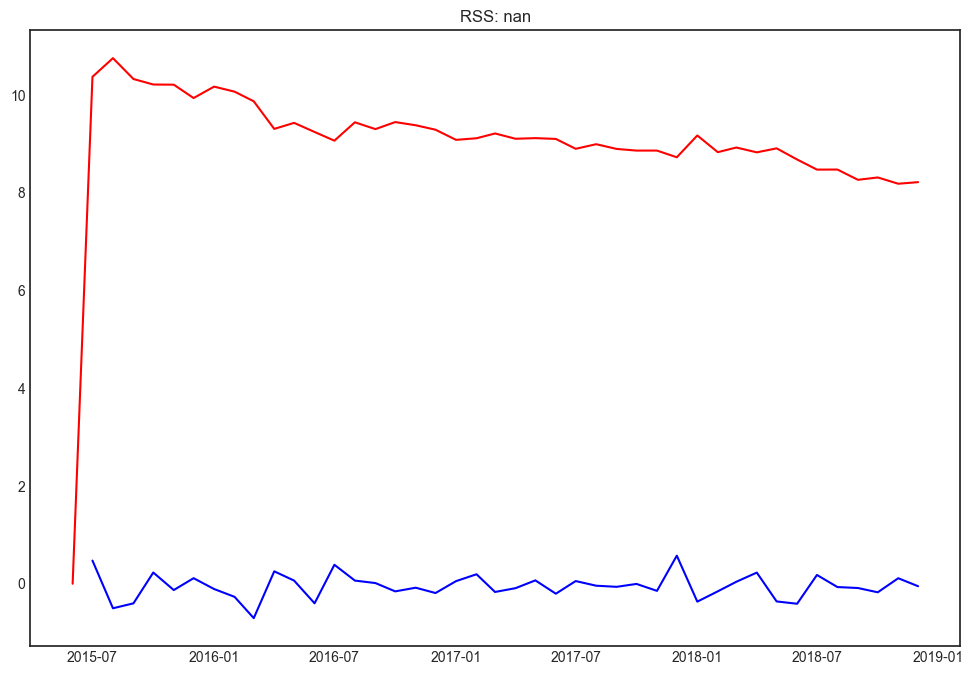

In [104]:
# Combined ARIMA model (p=2, d=1, q=2)
model = ARIMA(ts_log, order=(2, 1, 2))
results_ARIMA = model.fit()
print(results_ARIMA.summary())
plt.plot(ts_log_diff_active, color = 'blue')
plt.plot(results_ARIMA.fittedvalues, color="red")
plt.title("RSS: %.3f" % sum((results_ARIMA.fittedvalues - first_order_diff) ** 2))
plt.show()

<Figure size 1000x500 with 0 Axes>

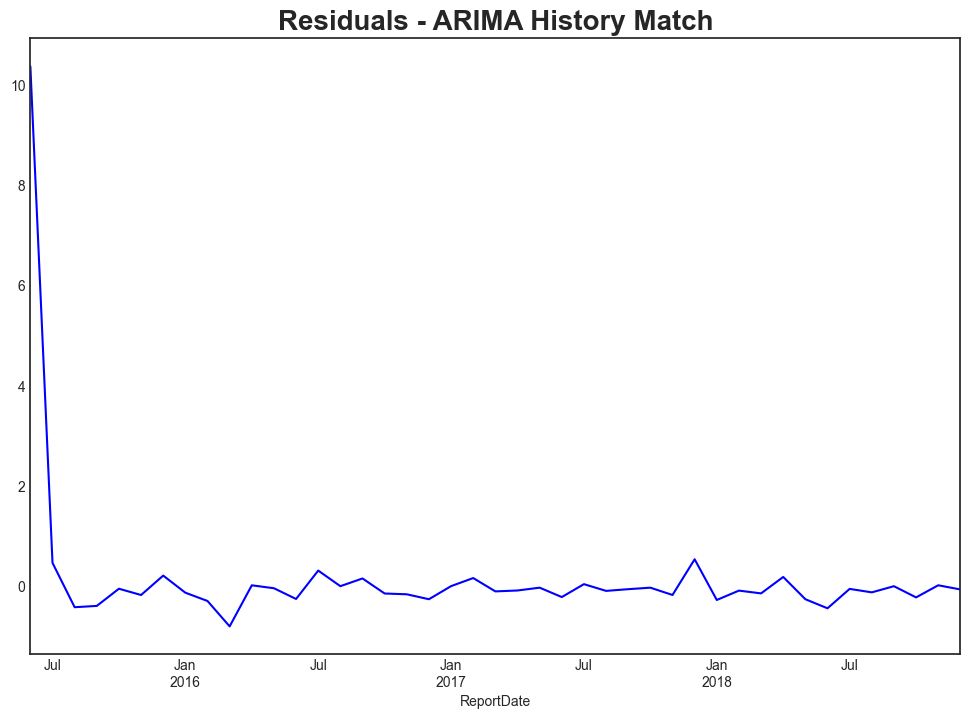

In [105]:
# residual and kde plot
plt.figure(figsize=(10, 5))# plot residual errors
residuals = DataFrame(results_ARIMA.resid)
residuals.plot(legend=None, color = 'blue')
plt.title('Residuals - ARIMA History Match', fontweight='bold', fontsize = 20)
plt.show()

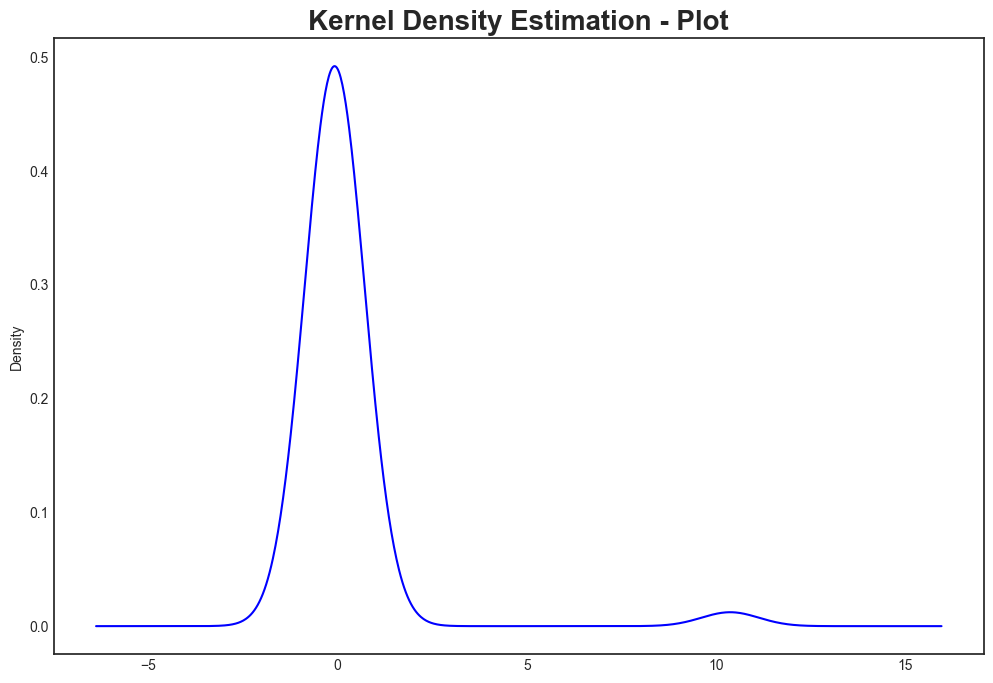

          0
count 43.00
mean   0.17
std    1.61
min   -0.79
25%   -0.19
50%   -0.08
75%    0.02
max   10.37


In [106]:
residuals.plot(kind='kde', legend=None, color = 'blue')
plt.title('Kernel Density Estimation - Plot', fontweight='bold', fontsize = 20)
plt.show()
print(residuals.describe())

In [108]:
from statsmodels.graphics.tsaplots import plot_predict

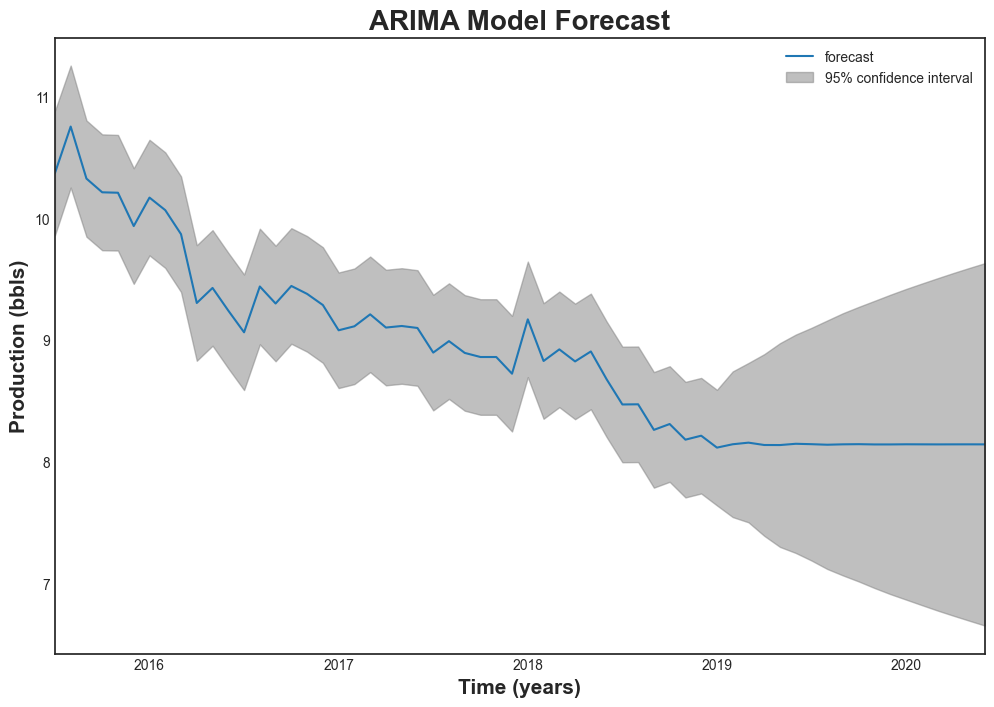

In [110]:

# forecast - ARIMA model
plot_predict(results_ARIMA, start=1, end=60 )
plt.title('ARIMA Model Forecast', fontweight='bold', fontsize = 20)
plt.xlabel('Time (years)', fontweight='bold', fontsize = 15)
plt.ylabel('Production (bbls)', fontweight='bold', fontsize = 15)
plt.show()

In [111]:
# Predictions converted to right units - ARIMA
predictions_ARIMA_diff = pd.Series(results_ARIMA.fittedvalues, copy=True)
predictions_ARIMA_diff_cumsum = predictions_ARIMA_diff.cumsum()
predictions_ARIMA_log = pd.Series(ts_log, index=ts_log.index)
predictions_ARIMA_log = predictions_ARIMA_log.add(predictions_ARIMA_diff_cumsum, fill_value=0)
predictions_ARIMA = np.exp(predictions_ARIMA_log)
print(predictions_ARIMA)

ReportDate
2015-06-01                                             31919.00
2015-07-01                                        1637061449.01
2015-08-01                                    46383992808299.20
2015-09-01                                948274192029176064.00
2015-10-01                           32552003800766416420864.00
2015-11-01                       777936583987467863134830592.00
2015-12-01                  18023050384221150122643736756224.00
2016-01-01              422693496141192634870813406990958592.00
2016-02-01          7618636817279333180563353216722369773568.00
2016-03-01      72941065995287919535986353584374893854588928.00
2016-04-01   10341510722354829796727738515050020254071358750...
2016-05-01   13733575358162894439463180061496828498928058603...
2016-06-01   95093320894534614596115878772380979825585683228...
2016-07-01   12119793146760627784337399672418222176768246264...
2016-08-01   16287163519858979561276094194407362724818466310...
2016-09-01   1809110042308414

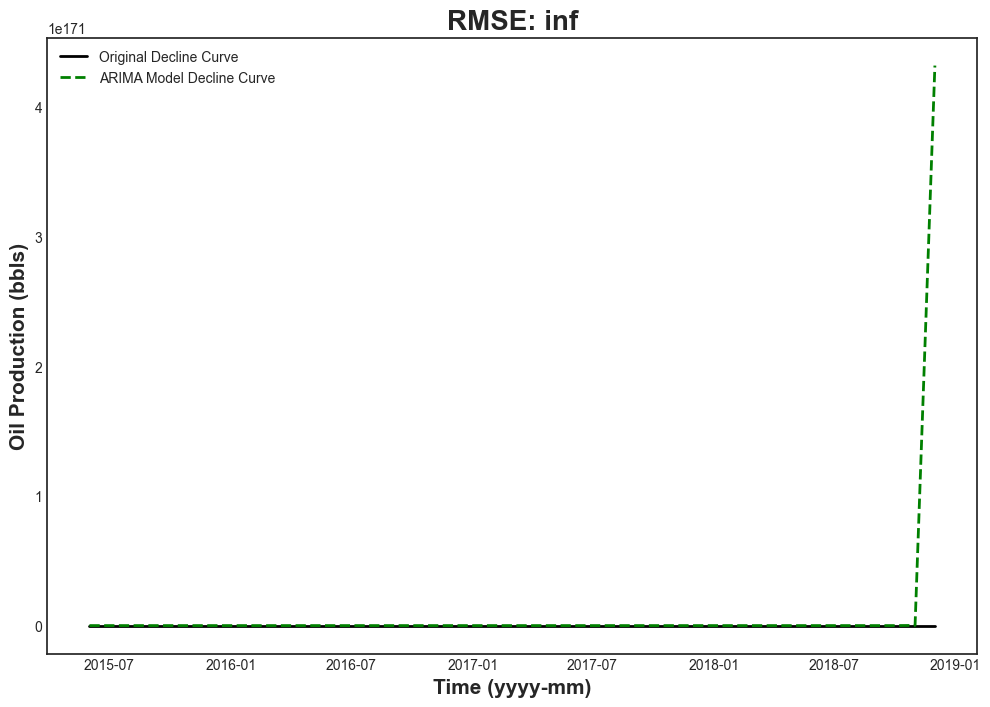

In [112]:
plt.figure(figsize=(12, 8))
plt.plot(timeseries_train, linewidth = 2, color = 'black')
plt.plot(predictions_ARIMA, linestyle = "--", color = 'green', linewidth = 2)
plt.title("RMSE: %.3f" % np.sqrt(sum((predictions_ARIMA - timeseries_train) ** 2) / len(timeseries_train)), fontweight='bold', fontsize = 20)
plt.gca().legend(("Original Decline Curve", "ARIMA Model Decline Curve"))
plt.xlabel('Time (yyyy-mm)', fontweight='bold', fontsize = 15)
plt.ylabel('Oil Production (bbls)', fontweight='bold', fontsize = 15)
plt.show()

In [118]:
forecast = results_ARIMA.forecast(steps=12)
forecast


2019-01-01   8.12
2019-02-01   8.15
2019-03-01   8.16
2019-04-01   8.14
2019-05-01   8.14
2019-06-01   8.15
2019-07-01   8.15
2019-08-01   8.14
2019-09-01   8.15
2019-10-01   8.15
2019-11-01   8.14
2019-12-01   8.14
Freq: MS, Name: predicted_mean, dtype: float64

In [119]:
# invert the differenced forecast results to covert to right units
X = timeseries_train.values
history = [x for x in X]
months_in_year = 12
Month = 1
# invert differenced value
def inverse_difference(history, yhat, interval=1):
    return yhat + history[-interval]

for yhat in forecast:
    inverted = inverse_difference(history, yhat, months_in_year)
    print(Month, inverted)
    history.append(inverted)
    Month += 1

history
forecast_12_months = history[-12:] # last 12 forecasted values
predictions_ARIMA = predictions_ARIMA.to_numpy()
forecast_12_months = np.array(forecast_12_months)

1 7381.1184688196145
2 6323.1461326689205
3 6582.159309669544
4 8269.140031578412
5 5761.1395712342155
6 3829.150028450685
7 4582.146705152086
8 4283.142252273503
9 3926.1455477348045
10 3297.146802056956
11 3690.144613199755
12 3509.1446901284244


In [120]:
print(predictions_ARIMA)
print(forecast_12_months)

[3.19190000e+004 1.63706145e+009 4.63839928e+013 9.48274192e+017
 3.25520038e+022 7.77936584e+026 1.80230504e+031 4.22693496e+035
 7.61863682e+039 7.29410660e+043 1.03415107e+048 1.37335754e+052
 9.50933209e+055 1.21197931e+060 1.62871635e+064 1.80911004e+068
 1.95781465e+072 2.13973623e+076 1.91418427e+080 1.77553906e+084
 1.95833851e+088 1.65868562e+092 1.36226852e+096 1.32923146e+100
 9.71546381e+103 7.51477551e+107 5.80646156e+111 3.98102264e+115
 2.80014009e+119 1.70920940e+123 1.86928134e+127 1.24679721e+131
 7.29632663e+134 5.70901474e+138 4.88455584e+142 2.51341007e+146
 9.81830318e+149 5.62089418e+153 2.51573697e+157 8.95141228e+160
 3.06072880e+164 1.22743867e+168 4.31936278e+171]
[7381.11846882 6323.14613267 6582.15930967 8269.14003158 5761.13957123
 3829.15002845 4582.14670515 4283.14225227 3926.14554773 3297.14680206
 3690.1446132  3509.14469013]


In [121]:
arima_model_results = np.concatenate((predictions_ARIMA, forecast_12_months))
arima_model_results

array([3.19190000e+004, 1.63706145e+009, 4.63839928e+013, 9.48274192e+017,
       3.25520038e+022, 7.77936584e+026, 1.80230504e+031, 4.22693496e+035,
       7.61863682e+039, 7.29410660e+043, 1.03415107e+048, 1.37335754e+052,
       9.50933209e+055, 1.21197931e+060, 1.62871635e+064, 1.80911004e+068,
       1.95781465e+072, 2.13973623e+076, 1.91418427e+080, 1.77553906e+084,
       1.95833851e+088, 1.65868562e+092, 1.36226852e+096, 1.32923146e+100,
       9.71546381e+103, 7.51477551e+107, 5.80646156e+111, 3.98102264e+115,
       2.80014009e+119, 1.70920940e+123, 1.86928134e+127, 1.24679721e+131,
       7.29632663e+134, 5.70901474e+138, 4.88455584e+142, 2.51341007e+146,
       9.81830318e+149, 5.62089418e+153, 2.51573697e+157, 8.95141228e+160,
       3.06072880e+164, 1.22743867e+168, 4.31936278e+171, 7.38111847e+003,
       6.32314613e+003, 6.58215931e+003, 8.26914003e+003, 5.76113957e+003,
       3.82915003e+003, 4.58214671e+003, 4.28314225e+003, 3.92614555e+003,
       3.29714680e+003, 3

In [122]:
timeseries_train.values # oil rate - train
timeseries_test # oil rate - test
forecast_12_months # oil rate - forecast

ts_np = timeseries_train.to_numpy()
ts_forecast = np.array(forecast_12_months)
ts_test_np = timeseries_test.to_numpy()

actual = np.concatenate([ts_np, ts_test_np])
actual = np.delete(actual, -1)
actual

forecast = np.concatenate([predictions_ARIMA, ts_forecast])
forecast = np.delete(forecast, -1)
forecast

time = pd.date_range(start='6/1/2015', periods= 54, freq='MS')

In [123]:
rmse = sqrt(mean_squared_error(actual, forecast))
print("RMSE - ARIMA Method:", rmse)

RMSE - ARIMA Method: inf
